# Обнаружение фальшивых новостей

Фальшивые новости — это ложная информация, распространяемая через социальные сети и другие сетевые СМИ для достижения политических или идеологических целей.

Твоя  задача -  используя библиотеку sklearn построить модель классического машинного обучения, которая может с высокой точностью более 90% определять, является ли новость реальной (REAL） или фальшивой（FAKE).

Ты должен самостоятельно изучить и применить к задаче TfidfVectorizer для извлечения признаков из текстовых данных и PassiveAggressiveClassifier.

Ты  можешь использовать данный [датасет](https://storage.yandexcloud.net/academy.ai/practica/fake_news.csv) для обучения.

Построй матрицу ошибок (confusion matrix). Представь, что ваш заказчик очень любит графики и диаграммы. Визуализируй для него результаты там, где это возможно.

In [86]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [87]:
# 1. Загрузка данных
url = "https://storage.yandexcloud.net/academy.ai/practica/fake_news.csv"
data = pd.read_csv(url)

# Проверка на наличие пропущенных значений
data.dropna(inplace=True)

Посмотрим распределение классов в вашем наборе данных, чтобы понять баланс между ними.

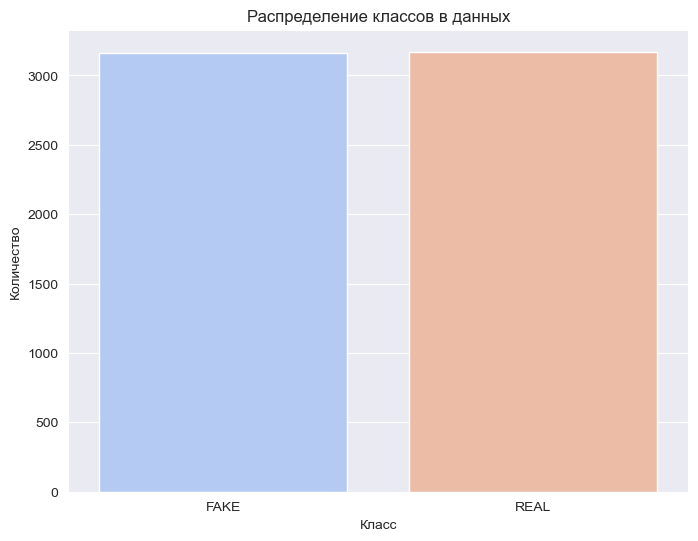

In [88]:
# Визуализация распределения классов
plt.figure(figsize=(8, 6))
sns.countplot(x=data['label'], hue=data['label'], palette='coolwarm', legend=False)
plt.title('Распределение классов в данных')
plt.xlabel('Класс')
plt.ylabel('Количество')
plt.show()

label указывает модели является ли новость фальшивой или настоящей.
Остальные данные используются для обучения модели.

Так же разделяем данные на тренеровочные и тестовые в соотношении 80/20.

In [89]:
# 2. Разделение на признаки и целевую переменную
X = data['text']
y = data['label']

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Текст преобразуется в числовые данные с помощью TfidfVectorizer. Это необходимо, так как алгоритмы машинного обучения работают с числами, а не с текстом.

In [90]:
# 3. Преобразование текста в числовые признаки с помощью TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_df=0.7)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

In [91]:
# 4. Создание и обучение модели PassiveAggressiveClassifier
model = PassiveAggressiveClassifier(max_iter=50, random_state=42)
model.fit(X_train_tfidf, y_train)

# Предсказания на тестовой выборке
y_pred = model.predict(X_test_tfidf)

In [92]:
# 5. Оценка точности
accuracy = accuracy_score(y_test, y_pred)
print(f"Точность модели: {accuracy * 100:.2f}%")

Точность модели: 93.76%


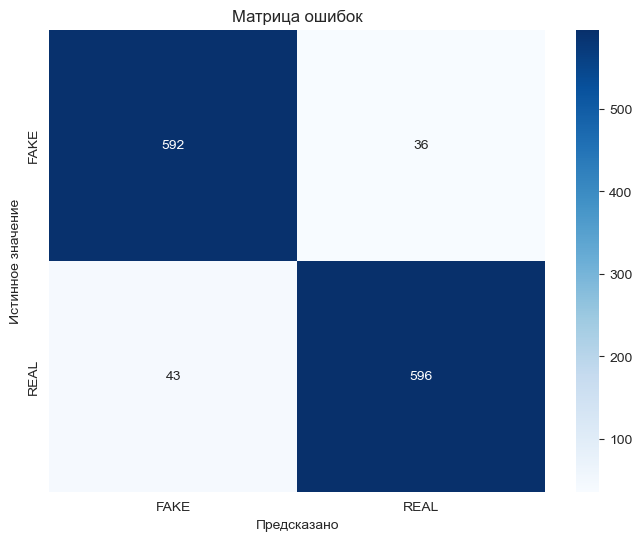

In [93]:
# 6. Матрица ошибок
conf_matrix = confusion_matrix(y_test, y_pred)

# Визуализация матрицы ошибок
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['FAKE', 'REAL'], yticklabels=['FAKE', 'REAL'])
plt.xlabel('Предсказано')
plt.ylabel('Истинное значение')
plt.title('Матрица ошибок')
plt.show()

Отобразим наиболее важные слова, которые модель считает значимыми для каждого класса.

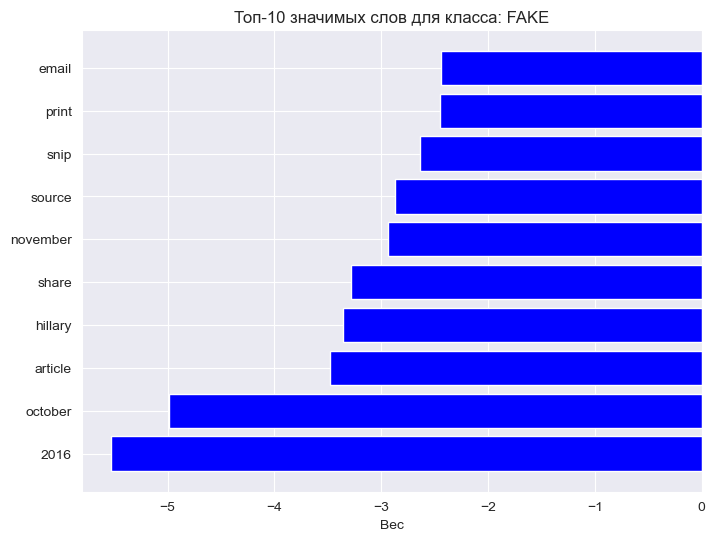

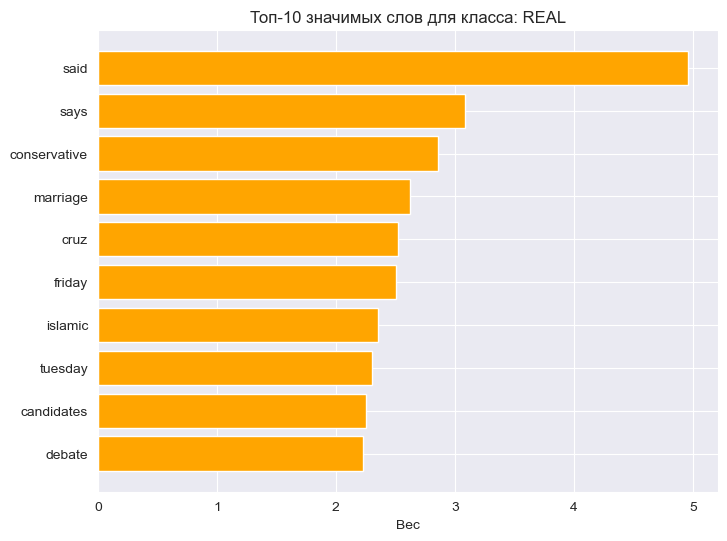

In [94]:
# 7. Визуализация важности слов (топ-10 для классов FAKE и REAL)
feature_names = tfidf_vectorizer.get_feature_names_out()
class_weights = model.coef_[0]  # Веса для бинарной классификации

# Топ-10 слов для класса FAKE (самые низкие веса)
top_fake_indices = np.argsort(class_weights)[:10]
top_fake_features = [feature_names[j] for j in top_fake_indices]
top_fake_weights = class_weights[top_fake_indices]

# Топ-10 слов для класса REAL (самые высокие веса)
top_real_indices = np.argsort(class_weights)[-10:]
top_real_features = [feature_names[j] for j in top_real_indices]
top_real_weights = class_weights[top_real_indices]

# Визуализация для класса FAKE
plt.figure(figsize=(8, 6))
plt.barh(top_fake_features, top_fake_weights, color='blue')
plt.xlabel('Вес')
plt.title('Топ-10 значимых слов для класса: FAKE')
plt.show()

# Визуализация для класса REAL
plt.figure(figsize=(8, 6))
plt.barh(top_real_features, top_real_weights, color='orange')
plt.xlabel('Вес')
plt.title('Топ-10 значимых слов для класса: REAL')
plt.show()


Посмотрим какой процент данных было классифицировано как FAKE и REAL.

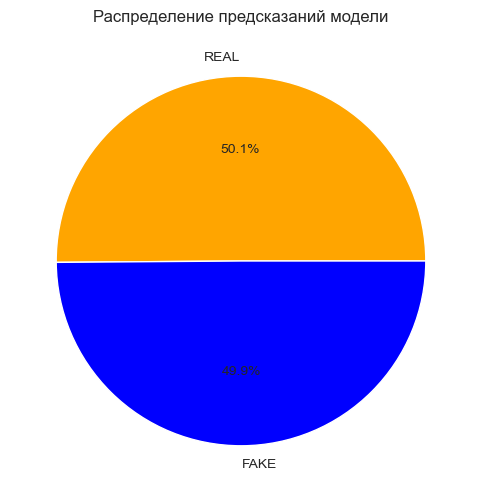

In [95]:
# 8. Круговая диаграмма предсказаний модели
pred_distribution = pd.Series(y_pred).value_counts(normalize=True)

plt.figure(figsize=(8, 6))
pred_distribution.plot(kind='pie', labels=['REAL', 'FAKE'], autopct='%1.1f%%', colors=['orange', 'blue'])
plt.title('Распределение предсказаний модели')
plt.ylabel('')  # Убираем метку оси
plt.show()

Классификационный отчет (Classification Report): Включает показатели точности (Precision), полноты (Recall) и F1-меры.

In [96]:
# 9. Отчет по классификации
print("Отчет по классификации:")
print(classification_report(y_test, y_pred))

Отчет по классификации:
              precision    recall  f1-score   support

        FAKE       0.93      0.94      0.94       628
        REAL       0.94      0.93      0.94       639

    accuracy                           0.94      1267
   macro avg       0.94      0.94      0.94      1267
weighted avg       0.94      0.94      0.94      1267



In [97]:
# 10. Примеры предсказаний
sample_indices = np.random.choice(len(X_test), 5, replace=False)
samples = X_test.iloc[sample_indices]
predictions = model.predict(X_test_tfidf[sample_indices])

# Создаем таблицу
result_df = pd.DataFrame({
    'Текст': samples,
    'Истинный класс': y_test.iloc[sample_indices].values,
    'Предсказание': predictions
})

print("\nПримеры предсказаний модели:")
print(result_df)


Примеры предсказаний модели:
                                                  Текст Истинный класс  \
5982  Indian princess watches over rare paleontologi...           FAKE   
3817  You are here: Home / US / Thomas Sowell Delive...           FAKE   
245   The chaotic scene -- accompanied by loud chant...           REAL   
3365  Obama Admits to Rigged Elections back in 2008 ...           FAKE   
544   The presidential candidates are laser-focused ...           REAL   

     Предсказание  
5982         FAKE  
3817         FAKE  
245          REAL  
3365         FAKE  
544          REAL  
